# Lecture 11. Graph Neural Networks for Molecules

**PHYG004 · Sogang University · 2026 Spring**
**Instructor:** Prof. Young Woo Choi

## Today's mission

Build a graph neural network from scratch and train it on the same Tetris dataset Friday's lecture (L12) will use. Two failure modes are exposed that motivate equivariance.

1. A flat-coordinate MLP fails on rotated test inputs.
2. A distance-only graph network (SchNet style) is rotation-invariant, but cannot distinguish a chiral pair.

The cliff-hanger: Friday replaces scalar messages with direction-aware tensorial messages and recovers both.

![water as a graph](https://yw-choi.github.io/PHYG004/lectures/11/images/00_motivation_water_graph.png)

## Roadmap

| Cell | Topic |
|---|---|
| 1–2 | install, imports |
| 3–4 | what a graph is; node and edge features |
| 5 | permutation invariance — the constraint that drives architecture choice |
| 6–7 | MPNN three-step recipe (Gilmer et al., 2017). **Checkpoint A** |
| 8 | reproducing the same step with `jraph` |
| 9–10 | Tetris dataset, fully-connected radius graph |
| 11 | a vanilla MLP baseline. Fails on rotation |
| 12 | SchNet — a continuous-filter, distance-only MPNN |
| 13 | training SchNet. **Checkpoint B**: 87.5% ceiling |
| 14 | rotation test (passes), chirality test (fails) |
| 15 | recap → Friday |

## Source

* Gilmer et al., 2017. *Neural Message Passing for Quantum Chemistry.* [arXiv:1704.01212](https://arxiv.org/abs/1704.01212).
* Schütt et al., 2017. *SchNet: A continuous-filter convolutional neural network for modeling quantum interactions.* [arXiv:1706.08566](https://arxiv.org/abs/1706.08566).
* Thomas et al., 2018. *Tensor Field Networks.* [arXiv:1802.08219](https://arxiv.org/abs/1802.08219).

## Runtime

Use **Colab CPU**. The dataset is 8 examples; GPU adds latency without speedup.


## Cell 1. Install packages

Six packages.

* `jax`, `jraph`, `flax`, `optax` — core JAX stack and graph utilities.
* `e3nn-jax` — used for one helper today; the equivariant features come on Friday.
* `networkx` — graph visualization.

Do **not** reinstall `jax` itself in Colab; the matched `jaxlib` is already there.


In [1]:
!pip install -q "e3nn-jax>=0.20.8,<0.22" flax optax jraph networkx tqdm matplotlib

zsh:1: command not found: pip


## Cell 2. Imports and setup

`float64` keeps numerical sanity checks crisp. A fixed seed makes results reproducible.


In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import flax
import flax.linen as nn
import jraph
import optax
import e3nn_jax as e3nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import networkx as nx

SEED = 42
key = jax.random.PRNGKey(SEED)

print("jax    :", jax.__version__)
print("jraph  :", jraph.__version__)
print("flax   :", flax.__version__)
print("default dtype:", jnp.zeros(1).dtype)

jax    : 0.10.0
jraph  : 0.0.6.dev0
flax   : 0.12.7
default dtype: float64


## Cell 3. The graph data structure

A graph is a pair $G = (V, E)$ with

* a finite set of **nodes** (vertices) $V = \{v_1, v_2, \ldots, v_N\}$,
* a set of **edges** $E \subseteq V \times V$ connecting node pairs.

Each node carries a **feature vector** $h_i \in \mathbb{R}^d$. Each edge $(i, j) \in E$ may carry an **edge feature** $e_{ij}$ (e.g. the interatomic distance).

For a molecule, the natural mapping is the following.

| Graph object | Molecular meaning |
|---|---|
| Node $i$ | atom $i$ |
| Node feature $h_i$ | atomic number, charge, embedding |
| Edge $(i, j)$ | bond, or pair within distance cutoff |
| Edge feature $e_{ij}$ | distance, bond type |

The **neighborhood** of node $i$ is $\mathcal{N}(i) = \{\, j : (i, j) \in E \,\}$.

In code, edges are stored as two parallel arrays of length $|E|$: `senders[k]` and `receivers[k]` give the endpoints of the $k$-th *directed* edge. An undirected edge becomes two directed edges (one in each direction).

![graph anatomy: nodes, edges, features, neighborhood](https://yw-choi.github.io/PHYG004/lectures/11/images/01_graph_anatomy.png)


distance matrix:
[[0.    0.962 0.962]
 [0.962 0.    1.52 ]
 [0.962 1.52  0.   ]]



senders   : [0 0 1 2]
receivers : [1 2 0 0]
# directed edges: 4  (= 2 bonds * 2 directions)


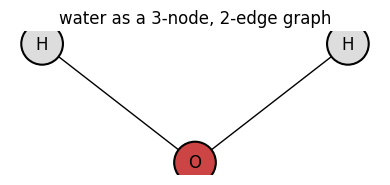

In [3]:
# Water (H2O) at experimental geometry, in angstroms.
water_atoms = ["O", "H", "H"]
water_pos = jnp.array([[ 0.00,  0.00, 0.00],
                       [ 0.76,  0.59, 0.00],
                       [-0.76,  0.59, 0.00]])

# Pairwise distance matrix.
dij = jnp.linalg.norm(water_pos[:, None, :] - water_pos[None, :, :], axis=-1)
print("distance matrix:")
print(np.round(np.array(dij), 3))

# Radius graph with cutoff 1.2 A: catches both O-H bonds, excludes the H-H pair (1.52 A).
cutoff = 1.2
mask = (dij < cutoff) & (dij > 0.0)
senders, receivers = jnp.where(mask)
print(f"\nsenders   : {np.array(senders)}")
print(f"receivers : {np.array(receivers)}")
print(f"# directed edges: {senders.shape[0]}  (= 2 bonds * 2 directions)")

# Visualize the graph.
G = nx.Graph()
G.add_nodes_from(range(3))
G.add_edges_from([(int(s), int(r)) for s, r in zip(senders, receivers) if s < r])
fig, ax = plt.subplots(figsize=(4.0, 3.0))
pos2d = {i: (float(water_pos[i, 0]), float(water_pos[i, 1])) for i in range(3)}
species_color = {"O": "#cc4444", "H": "#dddddd"}
nx.draw(G, pos2d,
        node_color=[species_color[a] for a in water_atoms],
        node_size=900, edgecolors="black", linewidths=1.5,
        labels={i: water_atoms[i] for i in range(3)},
        with_labels=True, ax=ax)
ax.set_aspect("equal"); ax.set_title("water as a 3-node, 2-edge graph")
plt.tight_layout(); plt.show()

## Cell 4. Permutation invariance

Atoms have no canonical order. Relabeling them is a bookkeeping change; the molecule is the same. Any model output that represents a *physical property of the graph* must therefore be unchanged under relabeling.

**Definition (graph-level invariance).** Let $\pi$ be a permutation of the $N$ nodes. A function $f$ of node features is *permutation invariant* if
$$f(h_{\pi(1)}, h_{\pi(2)}, \ldots, h_{\pi(N)}) \;=\; f(h_1, h_2, \ldots, h_N) \qquad \forall \pi.$$

**Definition (node-level equivariance).** A function $f$ that produces one output per node is *permutation equivariant* if
$$f\big(h_{\pi(\cdot)}\big)_i \;=\; f(h)_{\pi^{-1}(i)} \qquad \forall \pi.$$

A standard MLP applied to the *flat concatenation* $(h_1, h_2, \ldots, h_N)$ violates both: swapping two atoms produces a different output.

The canonical permutation-invariant operators on a multiset are
$$\bigoplus_{i} h_i \;\in\; \{\,\textstyle\sum_i h_i,\;\; \tfrac{1}{N}\sum_i h_i,\;\; \max_i h_i\,\}.$$

These are the standard **aggregation** operators in graph networks.

| Operator | Property |
|---|---|
| $\sum$ | preserves multiplicity (degree-sensitive) |
| mean | degree-normalized; loses degree information |
| max | selective; ignores all but the largest |

Default below: **sum**.

![permutation invariance: same multiset, two orderings, identical sum](https://yw-choi.github.io/PHYG004/lectures/11/images/02_permutation_invariance.png)


In [4]:
# Set of 4 features, two orderings.
x = jnp.array([1.0, 2.0, 3.0, 4.0])
perm = jnp.array([2, 0, 3, 1])
x_perm = x[perm]

# Sum / mean / max are permutation invariant.
print(f"sum    : original={x.sum():.3f},  permuted={x_perm.sum():.3f}")
print(f"mean   : original={x.mean():.3f},  permuted={x_perm.mean():.3f}")
print(f"max    : original={x.max():.3f},  permuted={x_perm.max():.3f}")

# Concat-and-Linear (the MLP analogue) is NOT permutation invariant.
W = jax.random.normal(jax.random.PRNGKey(0), (4,))
print(f"\ndot(x,    W) = {jnp.dot(x, W):.4f}")
print(f"dot(x_pi, W) = {jnp.dot(x_perm, W):.4f}   (different)")

sum    : original=10.000,  permuted=10.000
mean   : original=2.500,  permuted=2.500
max    : original=4.000,  permuted=4.000

dot(x,    W) = 4.4243
dot(x_pi, W) = 6.2377   (different)


## Cell 5. The MPNN recipe (Gilmer et al., 2017)

Almost every modern graph network for molecules — SchNet, DimeNet, PaiNN, NequIP, MACE — follows one template. A single layer is **three steps**.

### Step 1. Message

For each directed edge $(i, j) \in E$, compute
$$m_{ij} \;=\; \phi_M\!\left(h_i,\; h_j,\; e_{ij}\right),$$
with $\phi_M$ a learnable function (typically an MLP). Interpretation: $j$ packages information about itself and the edge $(i,j)$ to send to $i$.

### Step 2. Aggregate

Node $i$ collects all incoming messages with a permutation-invariant operator:
$$M_i \;=\; \bigoplus_{j \in \mathcal{N}(i)} m_{ij}.$$

### Step 3. Update

Combine the previous state with the aggregated message:
$$h_i^{\text{new}} \;=\; \phi_U\!\left(h_i,\; M_i\right),$$
again with a learnable $\phi_U$.

### Stacking layers

Repeating the recipe $L$ times propagates information across $L$-hop neighborhoods. The **receptive field** of node $i$ at layer $L$ is its $L$-hop neighborhood. Choosing $L$ matches the longest correlation length the task demands.

![MPNN three steps: message → aggregate → update](https://yw-choi.github.io/PHYG004/lectures/11/images/03_mpnn_three_steps.png)

![receptive field grows by one hop per layer](https://yw-choi.github.io/PHYG004/lectures/11/images/04_message_passing_propagation.png)


## Cell 6. One MPNN step on water — Checkpoint A

The cell below carries out a single layer by hand on the water graph from Cell 3, then verifies permutation equivariance numerically.

* Node feature: a 4-dim atomic embedding (one-hot-like).
* Edge feature: a single scalar $e_{ij} = \exp(-d_{ij})$.
* Message: $m_{ij} = h_j \cdot e_{ij}$ (a trivial $\phi_M$).
* Aggregation: sum.
* Update: $h_i^{\text{new}} = h_i + M_i$ (residual).


In [5]:
# Atomic embedding (4-dim, one-hot-like).
embed = {"O": jnp.array([1.0, 0.0, 0.0, 0.0]),
         "H": jnp.array([0.0, 1.0, 0.0, 0.0])}
h = jnp.stack([embed[a] for a in water_atoms])      # shape (3, 4)

# Edge feature: e_ij = exp(-d_ij).
edge_feat = jnp.exp(-dij[senders, receivers])[:, None]   # shape (E, 1)
print(f"h shape   : {h.shape}")
print(f"edge feat : {np.round(np.array(edge_feat.squeeze()), 4)}")

# Step 1. message  m_ij = h_j * e_ij
m_ij = h[senders] * edge_feat                       # (E, 4)

# Step 2. aggregate (sum into receivers)
M_i = jax.ops.segment_sum(m_ij, receivers, num_segments=h.shape[0])

# Step 3. update (residual)
h_new = h + M_i

print(f"\nh_new (after one MPNN step):")
print(np.round(np.array(h_new), 3))

# --- Sanity check: permutation equivariance ---
perm = jnp.array([2, 0, 1])
h_perm = h[perm]
inv_perm = jnp.argsort(perm)
m_p = h_perm[inv_perm[senders]] * edge_feat
M_p = jax.ops.segment_sum(m_p, inv_perm[receivers], num_segments=3)
h_p_new = h_perm + M_p
diff = jnp.max(jnp.abs(h_p_new[inv_perm] - h_new))
print(f"\npermutation-equivariance |diff| = {diff:.2e}")
assert diff < 1e-10
print("\n✅ Checkpoint A: one MPNN step is permutation-equivariant.")

h shape   : (3, 4)
edge feat : [0.3821 0.3821 0.3821 0.3821]

h_new (after one MPNN step):
[[1.    0.764 0.    0.   ]
 [0.382 1.    0.    0.   ]
 [0.382 1.    0.    0.   ]]



permutation-equivariance |diff| = 0.00e+00

✅ Checkpoint A: one MPNN step is permutation-equivariant.


## Cell 7. The same step in `jraph`

`jraph.GraphNetwork` packages the three-step recipe. The user provides:

* `update_edge_fn(edge, sender, receiver, glob)` $\to$ message,
* `update_node_fn(node, sender_msg, receiver_msg, glob)` $\to$ updated node feature,
* `aggregate_edges_for_nodes_fn` (the $\bigoplus$ operator).

`jraph` performs the segment-sum internally and returns a new `GraphsTuple` with updated nodes. The numerical result must match the hand calculation in Cell 6 exactly.


In [6]:
graph = jraph.GraphsTuple(
    nodes=h, edges=edge_feat,
    senders=senders, receivers=receivers,
    n_node=jnp.array([3]),
    n_edge=jnp.array([senders.shape[0]]),
    globals=None,
)

def edge_fn(edge, sender, receiver, glob):
    return sender * edge       # m_ij = h_j * e_ij

def node_fn(node, sender_msg, receiver_msg, glob):
    return node + receiver_msg # residual update

net = jraph.GraphNetwork(
    update_edge_fn=edge_fn,
    update_node_fn=node_fn,
    update_global_fn=None,
    aggregate_edges_for_nodes_fn=jraph.segment_sum,
)
out = net(graph)
print("jraph-updated nodes:")
print(np.round(np.array(out.nodes), 3))

diff = jnp.max(jnp.abs(out.nodes - h_new))
print(f"\n|jraph - manual| = {diff:.2e}")
assert diff < 1e-10
print("jraph reproduces the manual step exactly.")

jraph-updated nodes:
[[1.    0.764 0.    0.   ]
 [0.382 1.    0.    0.   ]
 [0.382 1.    0.    0.   ]]

|jraph - manual| = 0.00e+00
jraph reproduces the manual step exactly.


## Cell 8. The Tetris dataset

Eight 4-atom shapes on the integer lattice (Thomas et al., 2018, Section 4.1). Friday's lecture uses the same dataset.

| Label | Name | Description |
|---|---|---|
| 0 | `chiral_1` | chiral, one handedness |
| 1 | `chiral_2` | mirror image of `chiral_1` |
| 2 | `square` | 2×2 flat square |
| 3 | `line` | 4 atoms in a row |
| 4 | `corner` | three legs from a corner |
| 5 | `L` | L-shape |
| 6 | `T` | T-shape |
| 7 | `zigzag` | zigzag |

Two facts drive everything below.

**Fact 1 (chiral pair has identical distance multisets).** `chiral_1` and `chiral_2` are mirror images, not rotations of one another. Every pairwise distance is the same:
$$\{r_{ij}\}_{\text{chiral\_1}} = \{r_{ij}\}_{\text{chiral\_2}}.$$
Any model that depends on $\{r_{ij}\}$ alone produces *identical* outputs on both, so the maximum achievable training accuracy is $\tfrac{7}{8} = 87.5\%$.

**Fact 2 (a small radius cutoff hides too much).** With a 1.1 cutoff (nearest neighbors only), several non-chiral shapes (`line`, `zigzag`, `L`, and even `chiral_1`) reduce to graph-isomorphic 4-vertex paths with all edge lengths equal to 1. Those classes become indistinguishable too. We therefore use a **fully-connected graph** (cutoff 4.0) so the model receives the entire distance multiset.

![tetris shapes; chiral_1 and chiral_2 share an identical distance multiset](https://yw-choi.github.io/PHYG004/lectures/11/images/06_tetris_shapes.png)


chiral_1 distances : [1.    1.    1.    1.414 1.414 1.732]
chiral_2 distances : [1.    1.    1.    1.414 1.414 1.732]
|d1 - d2|_max = 0.00e+00   (= 0)


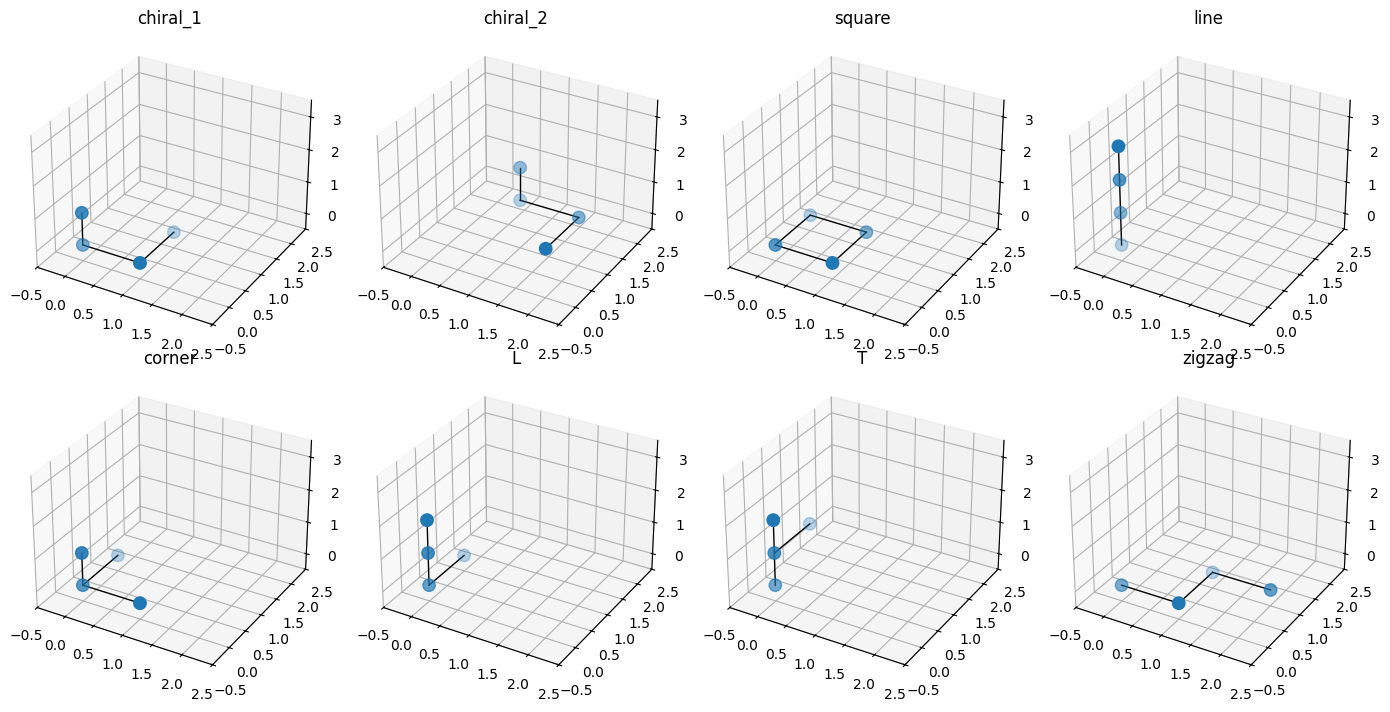

In [7]:
shape_names = ["chiral_1", "chiral_2", "square", "line",
               "corner", "L", "T", "zigzag"]
pos = jnp.array([
    [[0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0]],   # chiral_1
    [[1, 1, 1], [1, 1, 2], [2, 1, 1], [2, 0, 1]],   # chiral_2 = mirror(chiral_1)
    [[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0]],   # square
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 0, 3]],   # line
    [[0, 0, 0], [0, 0, 1], [0, 1, 0], [1, 0, 0]],   # corner
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 0]],   # L
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 1]],   # T
    [[0, 0, 0], [1, 0, 0], [1, 1, 0], [2, 1, 0]],   # zigzag
], dtype=jnp.float64)
labels = jnp.arange(8)

# Verify the chiral pair has identical pairwise-distance multisets.
def dist_multiset(p):
    d = jnp.linalg.norm(p[:, None, :] - p[None, :, :], axis=-1)
    iu = jnp.triu_indices(p.shape[0], k=1)
    return jnp.sort(d[iu])

d1, d2 = dist_multiset(pos[0]), dist_multiset(pos[1])
print(f"chiral_1 distances : {np.round(np.array(d1), 3)}")
print(f"chiral_2 distances : {np.round(np.array(d2), 3)}")
print(f"|d1 - d2|_max = {float(jnp.max(jnp.abs(d1 - d2))):.2e}   (= 0)")

# Plot all 8 shapes.
fig = plt.figure(figsize=(14, 7))
for i, name in enumerate(shape_names):
    ax = fig.add_subplot(2, 4, i + 1, projection="3d")
    p = np.asarray(pos[i])
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=80)
    for a_idx in range(4):
        for b_idx in range(a_idx + 1, 4):
            if np.linalg.norm(p[a_idx] - p[b_idx]) < 1.1:
                ax.plot(*zip(p[a_idx], p[b_idx]), color="black", lw=1)
    ax.set_title(name)
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5); ax.set_zlim(-0.5, 3.5)
plt.tight_layout(); plt.show()

## Cell 9. Building the batched graph dataset

For each shape we build a fully-connected directed graph (cutoff 4.0 covers the longest distance, $r = 3$ in the line shape). All 8 graphs are stacked into one `jraph.GraphsTuple` for batched processing. Node feature: position; edge feature: built inside the model from positions.


In [8]:
def radius_graph(p, r_cut):
    n = p.shape[0]
    d = jnp.linalg.norm(p[:, None, :] - p[None, :, :], axis=-1)
    mask = (d < r_cut) & (d > 0.0)
    s, r = jnp.where(mask, size=n * (n - 1), fill_value=-1)
    keep = s >= 0
    return s[keep], r[keep]

def make_tetris_graphs(r_cut=4.0):
    gs = []
    for p, lab in zip(pos, labels):
        s, r = radius_graph(p, r_cut)
        gs.append(jraph.GraphsTuple(
            nodes=p, edges=None, senders=s, receivers=r,
            n_node=jnp.array([4]),
            n_edge=jnp.array([s.shape[0]]),
            globals=lab[None],
        ))
    return jraph.batch(gs)

graphs = make_tetris_graphs(r_cut=4.0)
print(f"total nodes : {int(graphs.n_node.sum())}   (= 8 shapes × 4 atoms)")
print(f"total edges : {int(graphs.n_edge.sum())}   (= 8 shapes × 4 × 3 directed)")
print(f"labels      : {graphs.globals}")

total nodes : 32   (= 8 shapes × 4 atoms)
total edges : 96   (= 8 shapes × 4 × 3 directed)
labels      : [0 1 2 3 4 5 6 7]


## Cell 10. Baseline 1 — flat-coordinate MLP

The simplest possible baseline. Concatenate the 4 atoms' coordinates into a single 12-dim vector, pass through a 2-hidden-layer MLP. No graph structure, no rotation invariance.

After training to 100% on the original orientations, the **rotation test** evaluates on 100 random rotations of each shape. Expected accuracy: $1/8 = 12.5\%$ — the random-guessing rate. Coordinates rotate, but the MLP treats every rotation as a brand-new input.


In [9]:
class FlatMLP(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(128)(x); x = nn.silu(x)
        x = nn.Dense(128)(x); x = nn.silu(x)
        return nn.Dense(8)(x)

X_train = pos.reshape(8, 12)
y_train = labels

mlp = FlatMLP()
mlp_params = mlp.init(jax.random.PRNGKey(0), X_train)
mlp_opt = optax.adam(0.01)
mlp_state = mlp_opt.init(mlp_params)

@jax.jit
def mlp_step(params, state, X, y):
    def loss_fn(p):
        logits = mlp.apply(p, X)
        return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, y)), logits
    grads, logits = jax.grad(loss_fn, has_aux=True)(params)
    updates, state = mlp_opt.update(grads, state)
    return optax.apply_updates(params, updates), state, jnp.mean(jnp.argmax(logits, axis=1) == y)

for s in range(500):
    mlp_params, mlp_state, mlp_train_acc = mlp_step(mlp_params, mlp_state, X_train, y_train)
print(f"MLP train acc            : {float(mlp_train_acc)*100:.1f}%")

# Random rotation matrix (det = +1).
def rand_rotation(key):
    A = jax.random.normal(key, (3, 3))
    Q, _ = jnp.linalg.qr(A)
    return Q * jnp.sign(jnp.linalg.det(Q))

rot_keys = jax.random.split(jax.random.PRNGKey(99), 100)
mlp_rot_acc = []
for k in rot_keys:
    R = rand_rotation(k)
    X_rot = (pos @ R.T).reshape(8, 12)
    pred = jnp.argmax(mlp.apply(mlp_params, X_rot), axis=1)
    mlp_rot_acc.append(float(jnp.mean(pred == labels)))
print(f"MLP rotated-test acc     : {np.mean(mlp_rot_acc)*100:.1f}%   (≈ random 1/8 = 12.5%)")

MLP train acc            : 100.0%


MLP rotated-test acc     : 15.4%   (≈ random 1/8 = 12.5%)


## Cell 11. Baseline 2 — SchNet (continuous-filter MPNN)

SchNet (Schütt et al., 2017) is the simplest serious MPNN for molecules. Three design choices make it natural and rotation-invariant.

1. **Scalar node features.** Initial $h_i$ is an atomic embedding (here a constant 1, since all atoms are equivalent in Tetris).

2. **Distance-only edge features.** Each edge feature is a smooth radial expansion of the interatomic distance,
$$\mathrm{RBF}(r_{ij}) \;=\; \big[\,e^{-\gamma (r_{ij} - \mu_k)^2}\,\big]_{k=1, \ldots, K}, \qquad \mu_k \in [0, r_{\max}].$$
A small MLP turns this into a learnable filter $W_{ij} = \mathrm{MLP}\big(\mathrm{RBF}(r_{ij})\big)$.

3. **Message by elementwise gating.** The sender feature is multiplied componentwise by the filter,
$$m_{ij} \;=\; \big(W^{(s)} h_j\big) \odot W_{ij}.$$

Because every quantity that enters the network depends only on $r_{ij} = \|\vec r_{ij}\|$, **the entire forward pass is invariant under any rotation of the input coordinates**. Direction information is discarded by construction.

![SchNet message construction: distance → RBF → filter → gate](https://yw-choi.github.io/PHYG004/lectures/11/images/05_schnet_block.png)


## Cell 12. Training SchNet on Tetris — Checkpoint B

We train for 1500 steps. Expected outcomes:

* train accuracy $\to 87.5\%$ exactly,
* `chiral_1` and `chiral_2` produce *identical* logits (their distance multisets are equal — the network cannot tell them apart even in principle),
* the rotated-test accuracy equals the train accuracy (rotation invariance is built in).


Training SchNet on Tetris (1500 steps)...


  0%|          | 0/1500 [00:00<?, ?it/s]


predictions : [1 1 2 3 4 5 6 7]
truth       : [0 1 2 3 4 5 6 7]
train acc   : 87.5%   (max 87.5%)


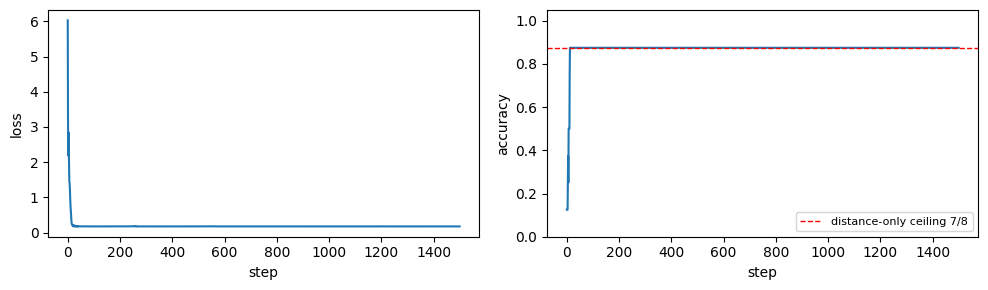


✅ Checkpoint B: SchNet hits the distance-only ceiling at 7/8 = 87.5%.


In [10]:
class SchNetLayer(nn.Module):
    hidden_dim: int = 64
    n_rbf: int = 32

    @nn.compact
    def __call__(self, h, gr, positions):
        rij = positions[gr.receivers] - positions[gr.senders]
        dij = jnp.linalg.norm(rij, axis=-1, keepdims=True)
        # radial basis expansion
        mu = jnp.linspace(0.0, 3.5, self.n_rbf)
        gamma = (self.n_rbf / 3.5) ** 2
        rbf = jnp.exp(-gamma * (dij - mu) ** 2)              # (E, n_rbf)
        # filter network
        W = nn.Dense(self.hidden_dim)(rbf); W = nn.silu(W)
        W = nn.Dense(self.hidden_dim)(W)
        # message: linearise sender, gate by filter
        s = nn.Dense(self.hidden_dim)(h[gr.senders])
        m = s * W
        # aggregate
        agg = jraph.segment_sum(m, gr.receivers, h.shape[0])
        # update (residual)
        u = nn.Dense(self.hidden_dim)(agg); u = nn.silu(u)
        u = nn.Dense(self.hidden_dim)(u)
        return h + u


class SchNetTetris(nn.Module):
    hidden_dim: int = 64
    n_layers: int = 4

    @nn.compact
    def __call__(self, gr):
        positions = gr.nodes
        h = jnp.ones((positions.shape[0], 1))
        h = nn.Dense(self.hidden_dim)(h)
        for _ in range(self.n_layers):
            h = SchNetLayer(self.hidden_dim)(h, gr, positions)
        # graph-level pool
        graph_idx = jnp.repeat(jnp.arange(gr.n_node.shape[0]),
                                gr.n_node, total_repeat_length=positions.shape[0])
        graph_h = jraph.segment_sum(h, graph_idx, gr.n_node.shape[0])
        graph_h = nn.Dense(self.hidden_dim)(graph_h); graph_h = nn.silu(graph_h)
        return nn.Dense(8)(graph_h)


schnet = SchNetTetris()
sch_params = schnet.init(jax.random.PRNGKey(SEED), graphs)
sch_opt = optax.adam(0.005)
sch_state = sch_opt.init(sch_params)

@jax.jit
def sch_step(params, state, gr):
    def loss_fn(p):
        logits = schnet.apply(p, gr)
        labs = gr.globals
        return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, labs)), logits
    grads, logits = jax.grad(loss_fn, has_aux=True)(params)
    updates, state = sch_opt.update(grads, state)
    return optax.apply_updates(params, updates), state, logits

@jax.jit
def sch_loss(params, gr):
    logits = schnet.apply(params, gr)
    return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, gr.globals))

print("Training SchNet on Tetris (1500 steps)...")
acc_hist, loss_hist = [], []
for s in tqdm(range(1500)):
    sch_params, sch_state, logits = sch_step(sch_params, sch_state, graphs)
    acc_hist.append(float(jnp.mean(jnp.argmax(logits, axis=1) == labels)))
    loss_hist.append(float(sch_loss(sch_params, graphs)))

preds = jnp.argmax(logits, axis=1)
print(f"\npredictions : {preds}")
print(f"truth       : {labels}")
print(f"train acc   : {acc_hist[-1]*100:.1f}%   (max 87.5%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(loss_hist); axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
axes[1].plot(acc_hist); axes[1].set_xlabel("step"); axes[1].set_ylabel("accuracy")
axes[1].axhline(0.875, color="red", ls="--", lw=1, label="distance-only ceiling 7/8")
axes[1].set_ylim(0, 1.05); axes[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

print("\n✅ Checkpoint B: SchNet hits the distance-only ceiling at 7/8 = 87.5%.")

## Cell 13. Rotation test, chirality inspection

Two probes.

**Rotation test.** Generate 100 random rotation matrices (uniform in $SO(3)$), apply each to the input coordinates, classify. SchNet uses only $r_{ij}$, so its logits are identical before and after rotation. The accuracy on rotated inputs must equal the accuracy on the originals.

**Chirality inspection.** Print the logits for `chiral_1` (label 0) and `chiral_2` (label 1). Their distance multisets are identical, hence the *logits are identical*. The maximum absolute difference is exactly 0.


SchNet rotated-test acc  : 87.5%   = train acc, by construction

chiral_1 logits : [10.065 10.111 -4.615 -6.449 -3.81  -2.536 -2.542 -2.448]
chiral_2 logits : [10.065 10.111 -4.615 -6.449 -3.81  -2.536 -2.542 -2.448]
|chiral_1 - chiral_2|_max = 0.000e+00   ← exactly 0; the chiral pair is invisible.


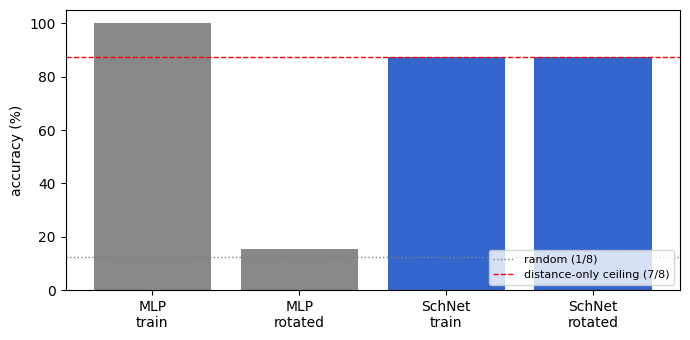

In [11]:
# Part 1. SchNet rotation test.
sch_rot_acc = []
for k in rot_keys:
    R = rand_rotation(k)
    pred = jnp.argmax(
        schnet.apply(sch_params, graphs._replace(nodes=graphs.nodes @ R.T)),
        axis=1,
    )
    sch_rot_acc.append(float(jnp.mean(pred == labels)))
print(f"SchNet rotated-test acc  : {np.mean(sch_rot_acc)*100:.1f}%   = train acc, by construction")

# Part 2. Chiral pair logits.
print("\nchiral_1 logits :", np.round(np.array(logits[0]), 3))
print("chiral_2 logits :", np.round(np.array(logits[1]), 3))
diff = float(jnp.max(jnp.abs(logits[0] - logits[1])))
print(f"|chiral_1 - chiral_2|_max = {diff:.3e}   ← exactly 0; the chiral pair is invisible.")

# Summary bar chart.
fig, ax = plt.subplots(figsize=(7, 3.5))
groups = ["MLP\ntrain", "MLP\nrotated", "SchNet\ntrain", "SchNet\nrotated"]
values = [float(mlp_train_acc) * 100, np.mean(mlp_rot_acc) * 100,
          acc_hist[-1] * 100, np.mean(sch_rot_acc) * 100]
colors = ["#888", "#888", "#3366cc", "#3366cc"]
ax.bar(groups, values, color=colors)
ax.axhline(12.5, color="gray", ls=":", lw=1, label="random (1/8)")
ax.axhline(87.5, color="red", ls="--", lw=1, label="distance-only ceiling (7/8)")
ax.set_ylim(0, 105); ax.set_ylabel("accuracy (%)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## Cell 14. Recap and the cliff-hanger

| Test | MLP | SchNet | What it shows |
|---|---|---|---|
| Train accuracy | 100% | 87.5% | SchNet bottlenecked by the chiral pair |
| Rotated test | $\approx 12\%$ | 87.5% | rotation invariance only when *built into the architecture* |
| Chiral pair | (random) | **identical logits** | distance-only is parity-blind |

Two failure modes, two architectural causes.

* The MLP fails on rotation because flat coordinates are not a rotation-invariant representation, and 8 examples are too few to learn rotation by augmentation.
* SchNet fails on chirality because the distance multiset $\{r_{ij}\}$ is *parity-symmetric*: it does not change under reflection.

The cure is to let messages carry **direction**, not just distance, and to track parity explicitly. That is the program of equivariant message passing — Friday.

![cliffhanger: Friday adds direction-aware messages](https://yw-choi.github.io/PHYG004/lectures/11/images/09_cliffhanger.png)

## Optional take-home exercises

**1. Aggregation operator.** Replace `segment_sum` by `segment_mean` in the SchNet layer. Does the chiral pair still collapse? Why must it?

**2. Cutoff sensitivity.** Re-run the SchNet training with `r_cut = 1.1` (nearest neighbours only). Predict the maximum train accuracy from graph-isomorphism considerations, then verify.

**3. Augmentation.** Train the flat MLP with on-the-fly random rotations applied to each batch. How many augmented copies per shape are needed to reach $> 90\%$ on a held-out rotated test?

## References

* Gilmer, Schoenholz, Riley, Vinyals, Dahl. *Neural Message Passing for Quantum Chemistry.* ICML 2017.
* Schütt, Arbabzadah, Chmiela, Müller, Tkatchenko. *Quantum-chemical insights from deep tensor neural networks.* Nat. Commun. 2017.
* Thomas, Smidt, Kearnes, Yang, Li, Kohlhoff, Riley. *Tensor Field Networks.* arXiv:1802.08219, 2018.
* Xu, Hu, Leskovec, Jegelka. *How Powerful are Graph Neural Networks?* ICLR 2019.
